In [1]:
## Importing Libraries

import os
import copy
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [2]:
## Setting Training Device & Paths

device = torch.device("cuda")
print(f"Device : {device}")

ROOT_DIR = Path.cwd().parent

DATASET_DIR = ROOT_DIR / "datasets" / "processed_dataset"

TRAIN_DIR = DATASET_DIR / "images" / "train"
VAL_DIR = DATASET_DIR / "images" / "val"
TEST_DIR = DATASET_DIR / "images" / "test"

MODELS_DIR = ROOT_DIR / "models"/ "CNN"
MODELS_DIR.mkdir(exist_ok=True)

print("Dataset Loaded.")

Device : cuda
Dataset Loaded.


In [3]:
## Applying Image Tranformers

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

print("Transforms Ready.")

Transforms Ready.


In [4]:
## Creating Dataset Class

from torch.utils.data import Dataset
from PIL import Image


class WeedDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform

        self.images = sorted(list(image_dir.glob("*")))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = self.images[idx]

        label_path = (self.label_dir / f"{image_path.stem}.txt")
        image = Image.open(image_path).convert("RGB")

        with open(label_path, "r") as f:
            line = f.readline().strip()

        class_id = int(line.split()[0])

        if self.transform:
            image = self.transform(image)

        return image, class_id

print("Custom Dataset Ready.")

Custom Dataset Ready.


In [5]:
## Creating Datasets

train_dataset = WeedDataset(TRAIN_DIR, DATASET_DIR / "labels" / "train", transform=train_transform)
val_dataset = WeedDataset(VAL_DIR, DATASET_DIR / "labels" / "val", transform=val_test_transform)
test_dataset = WeedDataset(TEST_DIR, DATASET_DIR / "labels" / "test", transform=val_test_transform)

print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

Train : 3948
Val   : 846
Test  : 847


In [6]:
## Creating DataLoaders

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("DataLoaders Ready.")

DataLoaders Ready.


In [7]:
## Inspecting Batch

images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("Classes in Batch:")
print(labels[:10])

Images Shape : torch.Size([64, 3, 224, 224])
Labels Shape : torch.Size([64])
Classes in Batch:
tensor([ 3,  9, 11,  4,  4,  6,  1,  3,  4,  7])


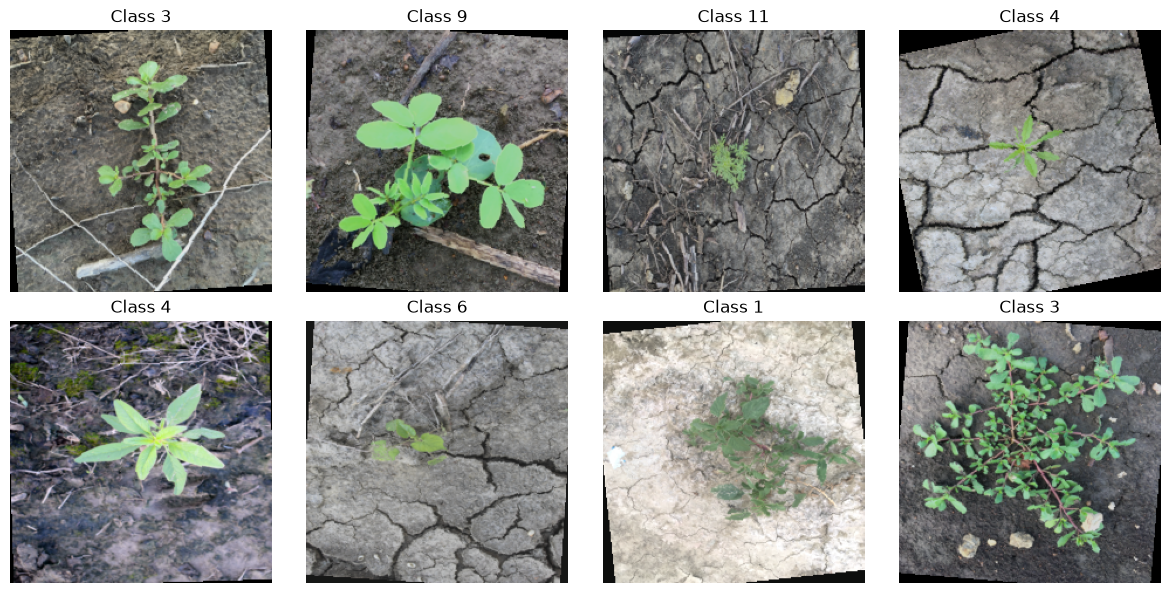

In [8]:
## Visualizing Training Images

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0).numpy()

    image = image * np.array([0.229, 0.224, 0.225])
    image = image + np.array([0.485, 0.456, 0.406])

    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(f"Class {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
## Loading ResNet18 Model

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 12)
model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=12, bias=True)


In [10]:
## Seeting Loss Function & Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=3)

print("Training Components Ready.")

Training Components Ready.


In [ ]:
## Training Function

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, total=len(loader), desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
## Validation Function

def validate(model, loader, criterion):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [13]:
## Checkpoint Helpers

CHECKPOINT_PATH = MODELS_DIR / "cnn_checkpoint.pth"
BEST_MODEL_PATH = MODELS_DIR / "best_cnn_model.pth"

def save_checkpoint(epoch, model, optimizer, best_acc, history):
    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "best_acc": best_acc, "history": history }, CHECKPOINT_PATH)

def load_checkpoint():
    if CHECKPOINT_PATH.exists():
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        print(
            f"Resuming from Epoch "
            f"{checkpoint['epoch'] + 1}")

        return (checkpoint["epoch"] + 1, checkpoint["best_acc"], checkpoint["history"])

    return 0, 0, {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

In [14]:
## Initializing Training 

NUM_EPOCHS = 25

start_epoch, best_acc, history = load_checkpoint()

print(f"Starting Epoch : {start_epoch}")
print(f"Best Accuracy  : {best_acc:.4f}")

Resuming from Epoch 1
Starting Epoch : 1
Best Accuracy  : 0.7920


In [15]:
## Training Loop

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_acc:
        best_acc = val_acc

        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best Model Saved.")

    save_checkpoint(epoch, model, optimizer, best_acc, history)

print("Training Complete.")


Epoch [2/25]


Training:   0%|          | 0/62 [00:00<?, ?it/s]

Train Loss: 0.5248 | Train Acc: 0.8447 | Val Loss: 0.5163 | Val Acc: 0.8345
Best Model Saved.

Epoch [3/25]


Training:   0%|          | 0/62 [00:00<?, ?it/s]

Train Loss: 0.3888 | Train Acc: 0.8868 | Val Loss: 0.4705 | Val Acc: 0.8487
Best Model Saved.

Epoch [4/25]


...

Train Loss: 0.0370 | Train Acc: 0.9947 | Val Loss: 0.4110 | Val Acc: 0.8783

Epoch [24/25]


Training:   0%|          | 0/62 [00:00<?, ?it/s]

Train Loss: 0.0375 | Train Acc: 0.9944 | Val Loss: 0.4193 | Val Acc: 0.8759

Epoch [25/25]


Training:   0%|          | 0/62 [00:00<?, ?it/s]

Train Loss: 0.0350 | Train Acc: 0.9957 | Val Loss: 0.4126 | Val Acc: 0.8818
Training Complete.


In [18]:
## Loading Best Model

model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

print("Best Model Loaded.")

print(device)
print(next(model.parameters()).device)

Best Model Loaded.
cuda
cuda:0


In [21]:
## Evalualtions

test_loss, test_acc = validate(model, test_loader, criterion)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Acc  : {test_acc:.4f}")

Test Loss : 0.4083
Test Acc  : 0.8808


In [22]:
## Classification Report

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        52
           1       0.90      0.86      0.88        44
           2       0.82      0.81      0.82        75
           3       0.87      0.88      0.87        88
           4       0.86      0.91      0.89       182
           5       0.98      0.91      0.95        68
           6       0.96      0.94      0.95       167
           7       0.83      0.95      0.88        20
           8       0.80      0.82      0.81        57
           9       0.96      0.90      0.93        29
          10       0.36      0.29      0.32        14
          11       0.92      0.90      0.91        51

    accuracy                           0.88       847
   macro avg       0.84      0.83      0.84       847
weighted avg       0.88      0.88      0.88       847



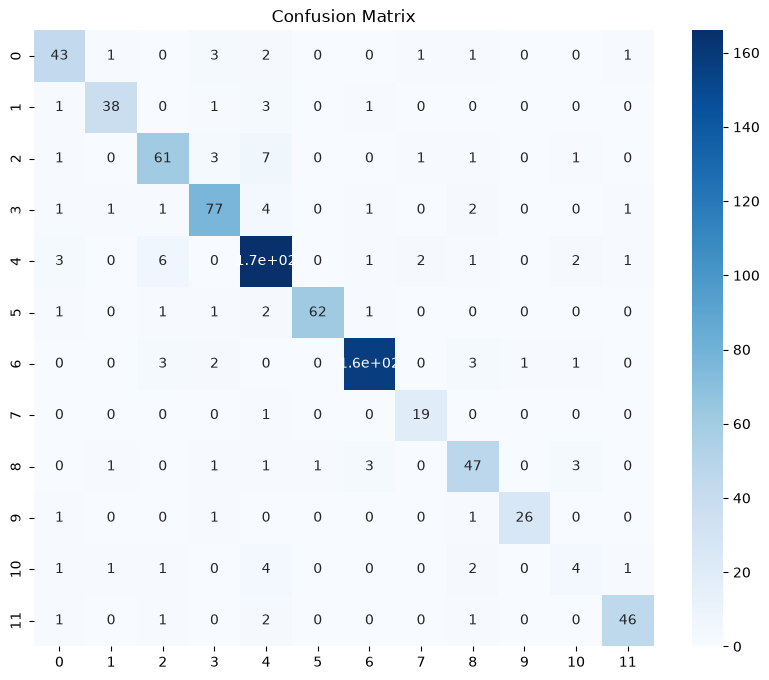

In [24]:
## Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()